/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 1.153831
Epoch 500, Loss: 0.025346
Epoch 1000, Loss: 0.000522
Epoch 1500, Loss: 0.000039
Epoch 2000, Loss: 0.000021
Epoch 2500, Loss: 0.000017
Epoch 3000, Loss: 0.000014
Epoch 3500, Loss: 0.000012


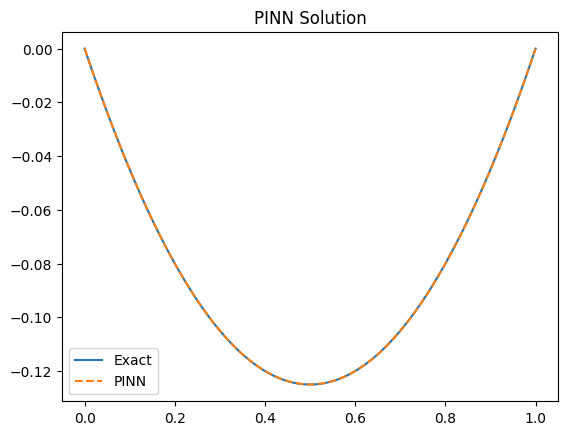

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Sigmoid(),
            nn.Linear(20, 20),
            nn.Sigmoid(),
            nn.Linear(20, 20),
            nn.Sigmoid(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)


def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    # First derivative
    u_x = torch.autograd.grad(u, x,grad_outputs=torch.ones_like(u), create_graph=True )[0]
    # Second derivative
    u_xx = torch.autograd.grad( u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True )[0]
    return u_xx - 1.0  

N_f = 100  
x_f = torch.rand((N_f, 1), device=device)
x_bc = torch.tensor([[0.0], [1.0]], device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 4000

for epoch in range(epochs):
    
    optimizer.zero_grad()

    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)  
    loss = loss_pde + loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

x_test = np.linspace(0, 1, 100)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1).to(device)

u_pred = model(x_test_tensor).detach().cpu().numpy()

u_exact = 0.5 * (x_test - 1) * x_test

plt.plot(x_test, u_exact, label="Exact")
plt.plot(x_test, u_pred, '--', label="PINN")
plt.legend()
plt.title("PINN Solution")
plt.show()

Epoch 0, Loss: 1.025136
Epoch 100, Loss: 0.483466
Epoch 200, Loss: 0.262981
Epoch 300, Loss: 0.016386
Epoch 400, Loss: 0.000000
Epoch 500, Loss: 0.000000
Epoch 600, Loss: 0.000000
Epoch 700, Loss: 0.000000
Epoch 800, Loss: 0.000000
Epoch 900, Loss: 0.000000
Epoch 1000, Loss: 0.000000
Epoch 1100, Loss: 0.000000
Epoch 1200, Loss: 0.000000
Epoch 1300, Loss: 0.000000
Epoch 1400, Loss: 0.000000
Epoch 1500, Loss: 0.000000
Epoch 1600, Loss: 0.000000
Epoch 1700, Loss: 0.000000
Epoch 1800, Loss: 0.000000
Epoch 1900, Loss: 0.000000
Epoch 2000, Loss: 0.000000
Epoch 2100, Loss: 0.000000
Epoch 2200, Loss: 0.000000
Epoch 2300, Loss: 0.000000
Epoch 2400, Loss: 0.000000
Epoch 2500, Loss: 0.000000
Epoch 2600, Loss: 0.000000
Epoch 2700, Loss: 0.000000
Epoch 2800, Loss: 0.000000
Epoch 2900, Loss: 0.000000


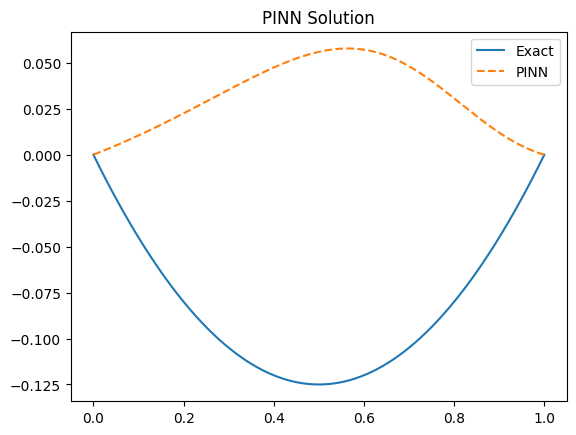

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Sigmoid(),
            nn.Linear(50, 50),
            nn.Sigmoid(),
            nn.Linear(50, 50),
            nn.Sigmoid(),
            nn.Linear(50, 1)
        )
        
    def forward(self, x):
        return self.net(x)

def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]
    
    return u_xx - 1.0  

N_f = 100  
x_f = torch.ones((N_f, 1), device=device)
x_bc = torch.tensor([[0.0], [1.0]], device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 3000

for epoch in range(epochs):
    
    optimizer.zero_grad()
    
    # PDE loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)  

    loss = loss_pde + loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

x_test = np.linspace(0, 1, 500)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1).to(device)

u_pred = model(x_test_tensor).detach().cpu().numpy()

u_exact = 0.5 * (x_test - 1) * x_test

plt.plot(x_test, u_exact, label="Exact")
plt.plot(x_test, u_pred, '--', label="PINN")
plt.legend()
plt.title("PINN Solution")
plt.show()

Epoch 0, Loss: 1.029958
Epoch 200, Loss: 0.511519
Epoch 400, Loss: 0.028182
Epoch 600, Loss: 0.009082
Epoch 800, Loss: 0.005751
Epoch 1000, Loss: 0.004361
Epoch 1200, Loss: 0.003401
Epoch 1400, Loss: 0.002661
Epoch 1600, Loss: 0.002061
Epoch 1800, Loss: 0.001565
Epoch 2000, Loss: 0.001154
Epoch 2200, Loss: 0.000818
Epoch 2400, Loss: 0.000551
Epoch 2600, Loss: 0.000349
Epoch 2800, Loss: 0.000205
Epoch 3000, Loss: 0.000110
Epoch 3200, Loss: 0.000053
Epoch 3400, Loss: 0.000023
Epoch 3600, Loss: 0.000009
Epoch 3800, Loss: 0.000004


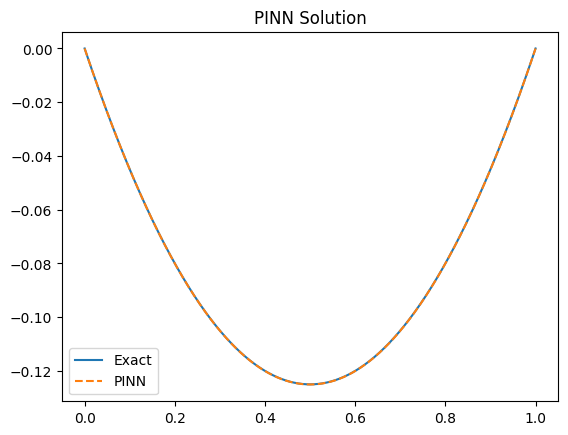

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Sigmoid(),
            nn.Linear(20, 20),
            nn.Sigmoid(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)


def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    # First derivative
    u_x = torch.autograd.grad(u, x,grad_outputs=torch.ones_like(u), create_graph=True )[0]
    # Second derivative
    u_xx = torch.autograd.grad( u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True )[0]
    return u_xx - 1.0  

N_f = 100  
x_f = torch.rand((N_f, 1), device=device)
x_bc = torch.tensor([[0.0], [1.0]], device=device)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 4000

for epoch in range(epochs):
    
    optimizer.zero_grad()

    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)  

    loss = loss_pde + loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

x_test = np.linspace(0, 1, 2000)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1).to(device)

u_pred = model(x_test_tensor).detach().cpu().numpy()

u_exact = 0.5 * (x_test - 1) * x_test

plt.plot(x_test, u_exact, label="Exact")
plt.plot(x_test, u_pred, '--', label="PINN")
plt.legend()
plt.title("PINN Solution")
plt.show()

2D

Using device: cuda
Epoch 0, Loss: 0.630085
Epoch 500, Loss: 0.000831
Epoch 1000, Loss: 0.000419
Epoch 1500, Loss: 0.000271
Epoch 2000, Loss: 0.000185
Epoch 2500, Loss: 0.000140
Epoch 3000, Loss: 0.000127
Epoch 3500, Loss: 0.000121
Epoch 4000, Loss: 0.000114
Epoch 4500, Loss: 0.000108
Epoch 5000, Loss: 0.000117
Epoch 5500, Loss: 0.000099
Epoch 6000, Loss: 0.000095
Epoch 6500, Loss: 0.000091
Epoch 7000, Loss: 0.000088
Epoch 7500, Loss: 0.000085

L2 Error: 3.752977e-02


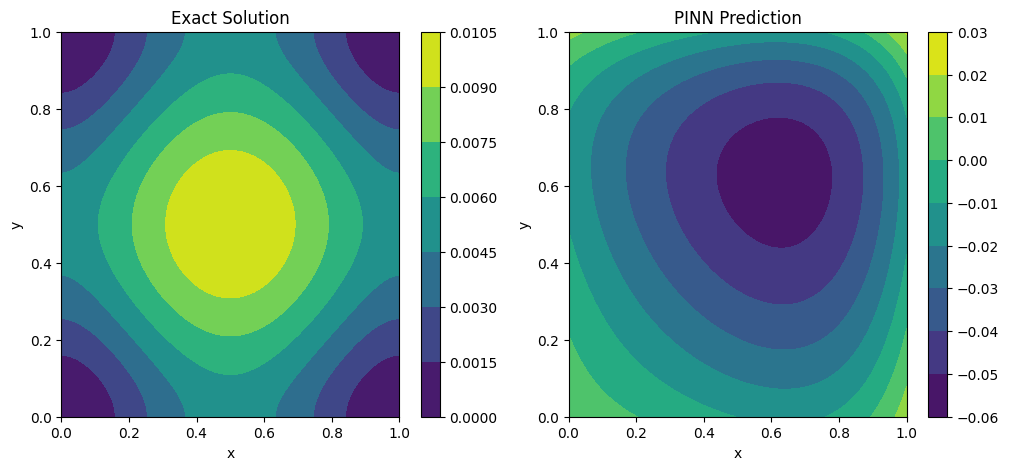

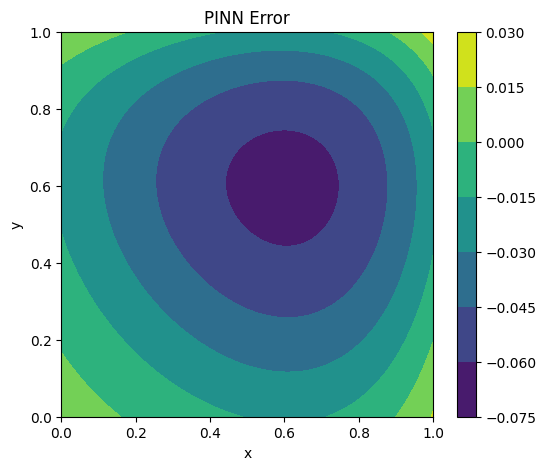

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# PINN Model
# -------------------------------------------------
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# -------------------------------------------------
# PDE Residual for Poisson Equation
# ∇²u = x² + y²
# -------------------------------------------------
def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    grads = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    u_x = grads[:, 0:1]
    u_y = grads[:, 1:2]
    
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]
    
    u_yy = torch.autograd.grad(
        u_y, x,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:, 1:2]
    
    # Poisson equation
    return u_xx + u_yy - (x[:, 0:1]**2 + x[:, 1:2]**2)

# -------------------------------------------------
# Training Data
# -------------------------------------------------
x_f = torch.rand((2000, 2), device=device)

N_bc = 200

x_left   = torch.cat([torch.zeros(N_bc, 1), torch.rand(N_bc, 1)], dim=1)
x_right  = torch.cat([torch.ones(N_bc, 1),  torch.rand(N_bc, 1)], dim=1)
y_bottom = torch.cat([torch.rand(N_bc, 1), torch.zeros(N_bc, 1)], dim=1)
y_top    = torch.cat([torch.rand(N_bc, 1), torch.ones(N_bc, 1)], dim=1)

x_bc = torch.cat([x_left, x_right, y_bottom, y_top], dim=0).to(device)

# -------------------------------------------------
# Model and Optimizer
# -------------------------------------------------
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 8000

# -------------------------------------------------
# Training Loop
# -------------------------------------------------
for epoch in range(epochs):
    
    optimizer.zero_grad()

    # PDE loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    # Boundary condition loss
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)

    # Total loss
    loss = loss_pde + loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# -------------------------------------------------
# Evaluation
# -------------------------------------------------
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
XY = np.stack([X.flatten(), Y.flatten()], axis=1)

XY_tensor = torch.tensor(XY, dtype=torch.float32).to(device)

# Exact solution
u_exact = (1/12)*(X**4 + Y**4) \
          - (1/6)*(X**3 + Y**3) \
          + (1/12)*(X**2 + Y**2)

# PINN prediction
u_pred = model(XY_tensor).detach().cpu().numpy()
u_pred = u_pred.reshape(100, 100)

# Error
u_error = u_pred - u_exact

# -------------------------------------------------
# Compute L2 Error
# -------------------------------------------------
u_exact_flat = u_exact.flatten()
u_pred_flat = u_pred.flatten()

l2_error = np.sqrt(np.mean((u_pred_flat - u_exact_flat) ** 2))
print(f"\nL2 Error: {l2_error:.6e}")

# -------------------------------------------------
# Plot Results
# -------------------------------------------------
plt.figure(figsize=(12, 5))

# Exact solution
plt.subplot(1, 2, 1)
plt.contourf(X, Y, u_exact)
plt.colorbar()
plt.title("Exact Solution")
plt.xlabel("x")
plt.ylabel("y")

# PINN prediction
plt.subplot(1, 2, 2)
plt.contourf(X, Y, u_pred)
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Difference between exact and predicted solutions
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, u_error)
plt.colorbar()
plt.title("PINN Error")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

learnable K factor

Using device: cuda
Epoch    0 | Loss: 1.043193e+00 | PDE: 1.000403e+00 | BC: 4.279048e-02 | k: 1.000000
Epoch  100 | Loss: 7.492363e-01 | PDE: 7.346617e-01 | BC: 1.497663e-02 | k: 0.973161
Epoch  200 | Loss: 1.479383e-01 | PDE: 5.568312e-02 | BC: 1.134508e-01 | k: 0.813173
Epoch  300 | Loss: 8.030601e-03 | PDE: 7.853712e-03 | BC: 2.319178e-04 | k: 0.762722
Epoch  400 | Loss: 5.670999e-04 | PDE: 5.616431e-04 | BC: 7.156823e-06 | k: 0.762462
Epoch  500 | Loss: 1.067770e-04 | PDE: 1.055544e-04 | BC: 1.603483e-06 | k: 0.762457
Epoch  600 | Loss: 5.778725e-05 | PDE: 5.732767e-05 | BC: 6.027556e-07 | k: 0.762456
Epoch  700 | Loss: 4.743318e-05 | PDE: 4.716247e-05 | BC: 3.550471e-07 | k: 0.762456
Epoch  800 | Loss: 4.112511e-05 | PDE: 4.092445e-05 | BC: 2.631803e-07 | k: 0.762456
Epoch  900 | Loss: 3.583120e-05 | PDE: 3.567202e-05 | BC: 2.087663e-07 | k: 0.762456

Freezing k at epoch 1000: 0.762456
Epoch 1000 | Loss: 3.133679e-05 | PDE: 3.120975e-05 | BC: 1.666147e-07 | k: 0.762456
Epoch 1100

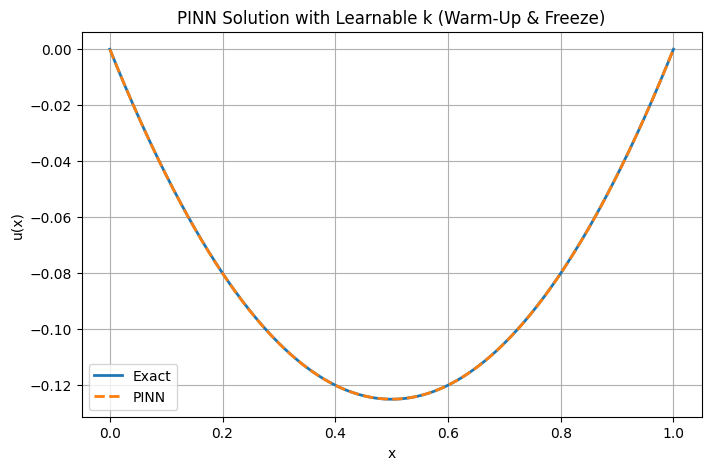


Final value of k: 0.762456


In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Sigmoid(),
            nn.Linear(50, 50),
            nn.Sigmoid(),
            nn.Linear(50, 50),
            nn.Sigmoid(),
            nn.Linear(50, 1)
        )
        
    def forward(self, x):
        return self.net(x)

def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)

    u_x = torch.autograd.grad(u, x,grad_outputs=torch.ones_like(u), create_graph=True)[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True)[0]
    
    return u_xx - 1.0  

# -------------------------------
# Training Data
# -------------------------------
N_f = 100

# Collocation points (can be randomized if desired)
x_f = torch.rand((N_f, 1), device=device)

# Boundary condition points
x_bc = torch.tensor([[0.0], [1.0]], dtype=torch.float32, device=device)

# -------------------------------
# Model and Optimizer
# -------------------------------
model = PINN().to(device)

log_k = nn.Parameter(torch.tensor(0.0, device=device))

optimizer = torch.optim.Adam(
    list(model.parameters()) + [log_k],
    lr=1e-3
)

epochs = 3000
warmup_epochs = 1000  
k_fixed = None
for epoch in range(epochs):
    
    optimizer.zero_grad()
    
    # PDE loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    # Boundary condition loss
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)
    k = torch.exp(log_k)
    if epoch == warmup_epochs:
        k_fixed = k.detach()
        log_k.requires_grad = False
        print(f"\nFreezing k at epoch {epoch}: {k_fixed.item():.6f}")

    if epoch >= warmup_epochs and k_fixed is not None:
        k = k_fixed
    loss = loss_pde + k * loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss.item():.6e} | "
            f"PDE: {loss_pde.item():.6e} | "
            f"BC: {loss_bc.item():.6e} | "
            f"k: {k.item():.6f}"
        )

# -------------------------------
# Evaluation
# -------------------------------
x_test = np.linspace(0, 1, 500)
x_test_tensor = torch.tensor(
    x_test, dtype=torch.float32
).unsqueeze(1).to(device)

u_pred = model(x_test_tensor).detach().cpu().numpy()

# Exact solution: u(x) = 0.5 * (x - 1) * x
u_exact = 0.5 * (x_test - 1) * x_test

# -------------------------------
# Plot Results
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_test, u_exact, label="Exact", linewidth=2)
plt.plot(x_test, u_pred, '--', label="PINN", linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PINN Solution with Learnable k (Warm-Up & Freeze)")
plt.legend()
plt.grid(True)
plt.show()

# Print final value of k
final_k = k_fixed.item() if k_fixed is not None else torch.exp(log_k).item()
print(f"\nFinal value of k: {final_k:.6f}")

Using device: cuda
Epoch     0 | Loss: 6.094947e-01 | PDE: 5.959336e-01 | BC: 1.356112e-02 | k: 1.000000
Epoch   500 | Loss: 6.517344e-04 | PDE: 4.533370e-04 | BC: 2.183684e-04 | k: 0.908545
Epoch  1000 | Loss: 1.760660e-04 | PDE: 1.057272e-04 | BC: 7.780403e-05 | k: 0.904051
Epoch  1500 | Loss: 1.132514e-04 | PDE: 4.586171e-05 | BC: 7.492329e-05 | k: 0.899449

Freezing k at epoch 2000: 0.893243
Epoch  2000 | Loss: 1.010207e-04 | PDE: 3.421822e-05 | BC: 7.478648e-05 | k: 0.893243
Epoch  2500 | Loss: 9.913163e-05 | PDE: 3.239204e-05 | BC: 7.471604e-05 | k: 0.893243
Epoch  3000 | Loss: 8.842212e-05 | PDE: 2.290765e-05 | BC: 7.334450e-05 | k: 0.893243
Epoch  3500 | Loss: 8.444047e-05 | PDE: 2.020244e-05 | BC: 7.191550e-05 | k: 0.893243
Epoch  4000 | Loss: 8.110196e-05 | PDE: 1.836217e-05 | BC: 7.023819e-05 | k: 0.893243
Epoch  4500 | Loss: 7.838285e-05 | PDE: 1.711138e-05 | BC: 6.859437e-05 | k: 0.893243
Epoch  5000 | Loss: 7.547563e-05 | PDE: 1.606008e-05 | BC: 6.651665e-05 | k: 0.893243

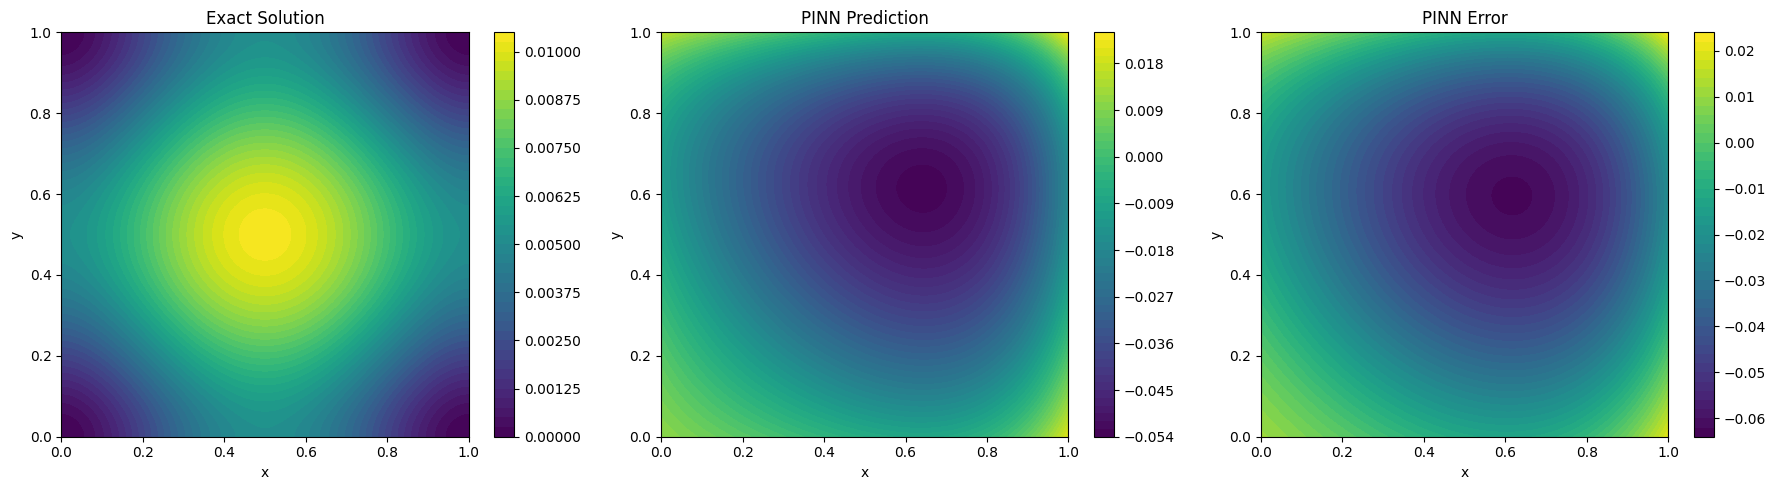


Final value of k: 0.893243
L2 Error: 3.534886e-02


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# PINN Model
# -------------------------------
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# -------------------------------
# PDE Residual: Poisson Equation
# -------------------------------
def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    grads = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    u_x = grads[:, 0:1]
    u_y = grads[:, 1:2]
    
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]
    
    u_yy = torch.autograd.grad(
        u_y, x,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:, 1:2]
    
    # Poisson equation: ∇²u = x² + y²
    return u_xx + u_yy - (x[:, 0:1]**2 + x[:, 1:2]**2)

# -------------------------------
# Training Data
# -------------------------------
# Collocation points
x_f = torch.rand((2000, 2), device=device)

# Boundary condition points
N_bc = 20

x_left   = torch.cat([torch.zeros(N_bc,1), torch.rand(N_bc,1)], dim=1)
x_right  = torch.cat([torch.ones(N_bc,1),  torch.rand(N_bc,1)], dim=1)
y_bottom = torch.cat([torch.rand(N_bc,1), torch.zeros(N_bc,1)], dim=1)
y_top    = torch.cat([torch.rand(N_bc,1), torch.ones(N_bc,1)], dim=1)

x_bc = torch.cat([x_left, x_right, y_bottom, y_top], dim=0).to(device)

# -------------------------------
# Model and Optimizer
# -------------------------------
model = PINN().to(device)

# Learnable log(k) ensures k > 0
log_k = nn.Parameter(torch.tensor(0.0, device=device))

optimizer = torch.optim.Adam(
    list(model.parameters()) + [log_k],
    lr=1e-3
)

# -------------------------------
# Training Parameters
# -------------------------------
epochs = 8000
warmup_epochs = 2000  # Train k initially
k_fixed = None

# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(epochs):
    
    optimizer.zero_grad()

    # PDE Loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    # Boundary Condition Loss
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)

    # Compute positive k
    k = torch.exp(log_k)

    # Freeze k after warm-up
    if epoch == warmup_epochs:
        k_fixed = k.detach()
        log_k.requires_grad = False
        print(f"\nFreezing k at epoch {epoch}: {k_fixed.item():.6f}")

    if epoch >= warmup_epochs and k_fixed is not None:
        k = k_fixed

    # Total Loss
    loss = loss_pde + k * loss_bc
    
    loss.backward()
    optimizer.step()

    # Logging
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss: {loss.item():.6e} | "
            f"PDE: {loss_pde.item():.6e} | "
            f"BC: {loss_bc.item():.6e} | "
            f"k: {k.item():.6f}"
        )

# -------------------------------
# Evaluation
# -------------------------------
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
XY = np.stack([X.flatten(), Y.flatten()], axis=1)

XY_tensor = torch.tensor(XY, dtype=torch.float32).to(device)

# Exact solution
u_exact = (1/12)*(X**4 + Y**4) \
          - (1/6)*(X**3 + Y**3) \
          + (1/12)*(X**2 + Y**2)

# PINN prediction
u_pred = model(XY_tensor).detach().cpu().numpy()
u_pred = u_pred.reshape(100, 100)

# Error
u_error = u_pred - u_exact

# -------------------------------
# Plot Results
# -------------------------------
plt.figure(figsize=(18, 5))

# Exact solution
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u_exact, levels=50, cmap="viridis")
plt.colorbar()
plt.title("Exact Solution")
plt.xlabel("x")
plt.ylabel("y")

# PINN prediction
plt.subplot(1, 3, 2)
plt.contourf(X, Y, u_pred, levels=50, cmap="viridis")
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")

# Error plot
plt.subplot(1, 3, 3)
plt.contourf(X, Y, u_error, levels=50, cmap="viridis")
plt.colorbar()
plt.title("PINN Error")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

# -------------------------------
# Final Metrics
# -------------------------------
final_k = k_fixed.item() if k_fixed is not None else torch.exp(log_k).item()
l2_error = np.sqrt(np.mean((u_pred - u_exact) ** 2))

print(f"\nFinal value of k: {final_k:.6f}")
print(f"L2 Error: {l2_error:.6e}")

Using device: cuda
Epoch 0, Loss: 9.912455e+01
Epoch 500, Loss: 6.936700e-01
Epoch 1000, Loss: 8.885828e-02
Epoch 1500, Loss: 5.399849e-02
Epoch 2000, Loss: 4.390092e-02
Epoch 2500, Loss: 3.470472e-02
Epoch 3000, Loss: 2.746221e-02
Epoch 3500, Loss: 2.292780e-02
Epoch 4000, Loss: 1.964765e-02
Epoch 4500, Loss: 1.699840e-02
Epoch 5000, Loss: 1.473699e-02
Epoch 5500, Loss: 1.231011e-02
Epoch 6000, Loss: 9.468699e-03
Epoch 6500, Loss: 6.509433e-03
Epoch 7000, Loss: 5.096727e-03
Epoch 7500, Loss: 8.398191e-03

L2 Error: 3.220499e-02


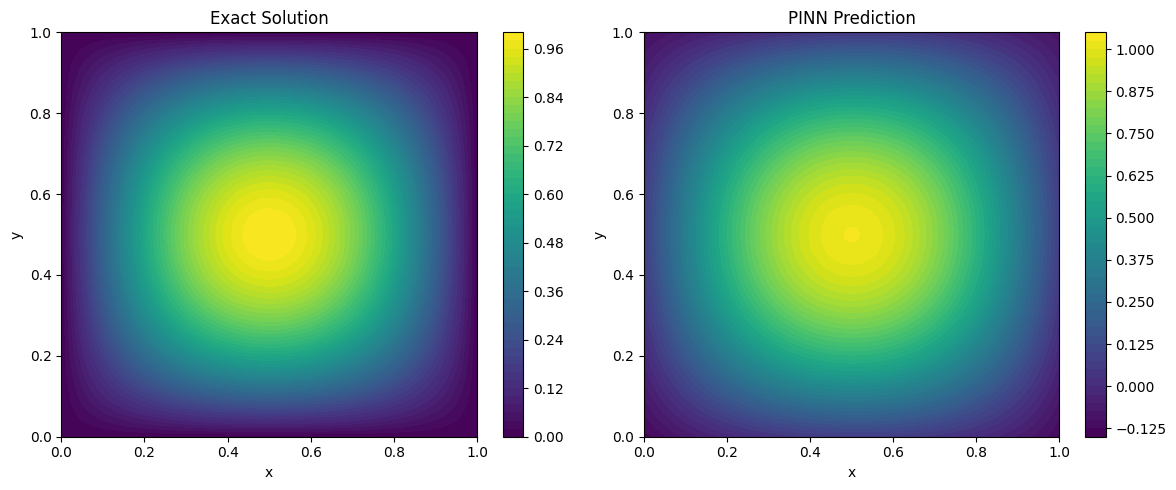

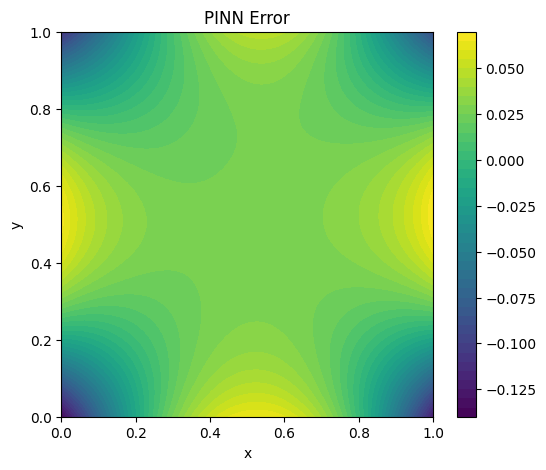

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# PINN Model
# -------------------------------------------------
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# -------------------------------------------------
# PDE Residual for Poisson Equation
# ∇²u = -2π² sin(πx) sin(πy)
# -------------------------------------------------
def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    grads = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    u_x = grads[:, 0:1]
    u_y = grads[:, 1:2]
    
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]
    
    u_yy = torch.autograd.grad(
        u_y, x,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:, 1:2]
    
    # Source term: -2π² sin(πx) sin(πy)
    f = -2 * (np.pi ** 2) * torch.sin(np.pi * x[:, 0:1]) * \
                                  torch.sin(np.pi * x[:, 1:2])
    
    return u_xx + u_yy - f

# -------------------------------------------------
# Training Data
# -------------------------------------------------
x_f = torch.rand((2000, 2), device=device)

N_bc = 20

x_left   = torch.cat([torch.zeros(N_bc, 1), torch.rand(N_bc, 1)], dim=1)
x_right  = torch.cat([torch.ones(N_bc, 1),  torch.rand(N_bc, 1)], dim=1)
y_bottom = torch.cat([torch.rand(N_bc, 1), torch.zeros(N_bc, 1)], dim=1)
y_top    = torch.cat([torch.rand(N_bc, 1), torch.ones(N_bc, 1)], dim=1)

x_bc = torch.cat([x_left, x_right, y_bottom, y_top], dim=0).to(device)

# -------------------------------------------------
# Model and Optimizer
# -------------------------------------------------
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 8000

# -------------------------------------------------
# Training Loop
# -------------------------------------------------
for epoch in range(epochs):
    
    optimizer.zero_grad()

    # PDE loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    # Boundary condition loss (u = 0 on boundary)
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)

    # Total loss
    loss = loss_pde + loss_bc
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

# -------------------------------------------------
# Evaluation
# -------------------------------------------------
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
XY = np.stack([X.flatten(), Y.flatten()], axis=1)

XY_tensor = torch.tensor(XY, dtype=torch.float32).to(device)

# Exact solution
u_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)

# PINN prediction
u_pred = model(XY_tensor).detach().cpu().numpy()
u_pred = u_pred.reshape(100, 100)

# Error
u_error = u_pred - u_exact

# -------------------------------------------------
# Compute L2 Error
# -------------------------------------------------
u_exact_flat = u_exact.flatten()
u_pred_flat = u_pred.flatten()

l2_error = np.sqrt(np.mean((u_pred_flat - u_exact_flat) ** 2))
print(f"\nL2 Error: {l2_error:.6e}")

# -------------------------------------------------
# Plot Results
# -------------------------------------------------
plt.figure(figsize=(12, 5))

# Exact solution
plt.subplot(1, 2, 1)
plt.contourf(X, Y, u_exact, levels=50)
plt.colorbar()
plt.title("Exact Solution")
plt.xlabel("x")
plt.ylabel("y")

# PINN prediction
plt.subplot(1, 2, 2)
plt.contourf(X, Y, u_pred, levels=50)
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

# Error plot
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, u_error, levels=50)
plt.colorbar()
plt.title("PINN Error")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Using device: cuda
Epoch     0 | Loss: 1.012870e+02 | PDE: 1.012479e+02 | BC: 3.909243e-02 | k: 1.000000
Epoch   500 | Loss: 4.183590e-01 | PDE: 2.424222e-01 | BC: 2.596348e-01 | k: 0.677632
Epoch  1000 | Loss: 1.096148e-01 | PDE: 9.361093e-02 | BC: 2.420428e-02 | k: 0.661199
Epoch  1500 | Loss: 6.205418e-02 | PDE: 4.943787e-02 | BC: 1.925425e-02 | k: 0.655248

Freezing k at epoch 2000: 0.648216
Epoch  2000 | Loss: 4.511867e-02 | PDE: 3.458918e-02 | BC: 1.624381e-02 | k: 0.648216
Epoch  2500 | Loss: 3.074229e-02 | PDE: 2.151475e-02 | BC: 1.423529e-02 | k: 0.648216
Epoch  3000 | Loss: 2.056140e-02 | PDE: 1.189146e-02 | BC: 1.337509e-02 | k: 0.648216
Epoch  3500 | Loss: 1.530501e-02 | PDE: 6.782852e-03 | BC: 1.314711e-02 | k: 0.648216
Epoch  4000 | Loss: 1.249794e-02 | PDE: 4.392840e-03 | BC: 1.250371e-02 | k: 0.648216
Epoch  4500 | Loss: 1.085610e-02 | PDE: 3.369101e-03 | BC: 1.155016e-02 | k: 0.648216
Epoch  5000 | Loss: 9.887625e-03 | PDE: 2.952768e-03 | BC: 1.069838e-02 | k: 0.648216

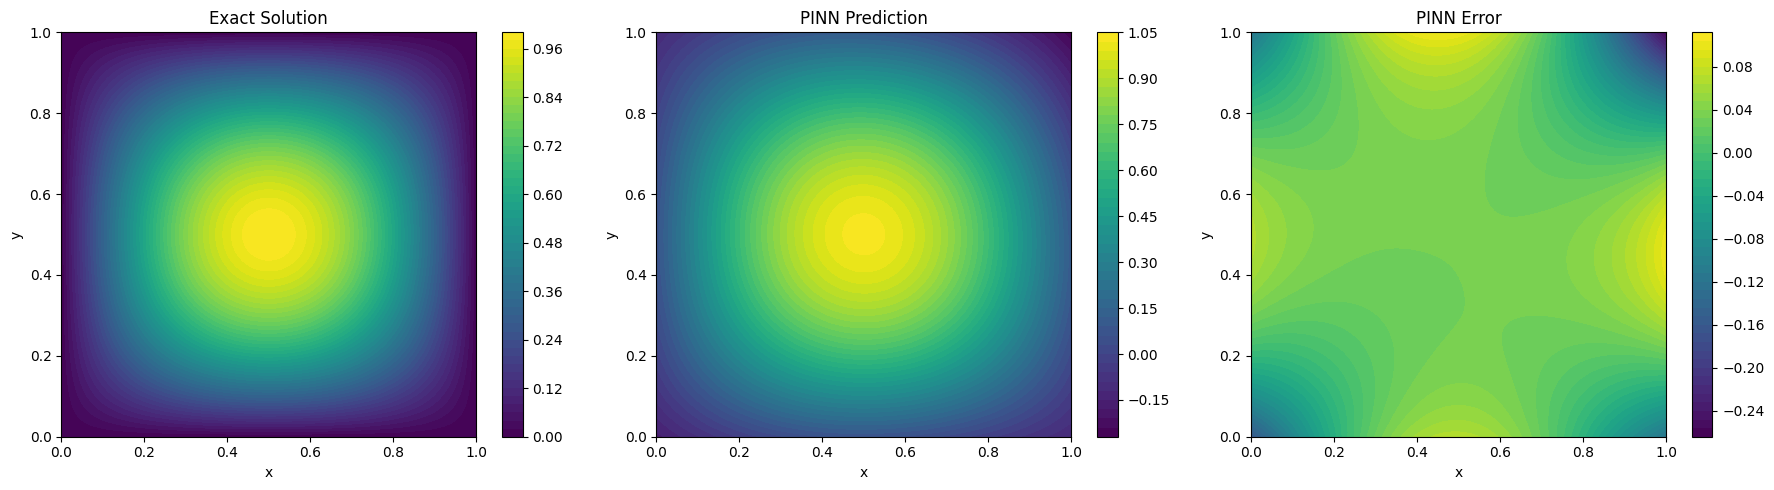


Final value of k: 0.648216
L2 Error: 4.565390e-02


In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# PINN Model
# -------------------------------
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# -------------------------------
# PDE Residual: Poisson Equation
# ∇²u = -2π² sin(πx) sin(πy)
# -------------------------------
def pde_residual(model, x):
    x.requires_grad_(True)
    
    u = model(x)
    
    grads = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    
    u_x = grads[:, 0:1]
    u_y = grads[:, 1:2]
    
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:, 0:1]
    
    u_yy = torch.autograd.grad(
        u_y, x,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:, 1:2]
    
    # Source term: -2π² sin(πx) sin(πy)
    f = -2 * (np.pi ** 2) * torch.sin(np.pi * x[:, 0:1]) * \
                                  torch.sin(np.pi * x[:, 1:2])
    
    return u_xx + u_yy - f

# -------------------------------
# Training Data
# -------------------------------
# Collocation points
x_f = torch.rand((2000, 2), device=device)

# Boundary condition points
N_bc = 20

x_left   = torch.cat([torch.zeros(N_bc, 1), torch.rand(N_bc, 1)], dim=1)
x_right  = torch.cat([torch.ones(N_bc, 1),  torch.rand(N_bc, 1)], dim=1)
y_bottom = torch.cat([torch.rand(N_bc, 1), torch.zeros(N_bc, 1)], dim=1)
y_top    = torch.cat([torch.rand(N_bc, 1), torch.ones(N_bc, 1)], dim=1)

x_bc = torch.cat([x_left, x_right, y_bottom, y_top], dim=0).to(device)

# -------------------------------
# Model and Optimizer
# -------------------------------
model = PINN().to(device)

# Learnable log(k) ensures k > 0
log_k = nn.Parameter(torch.tensor(0.0, device=device))

optimizer = torch.optim.Adam(
    list(model.parameters()) + [log_k],
    lr=1e-3
)

# -------------------------------
# Training Parameters
# -------------------------------
epochs = 8000
warmup_epochs = 2000  # Train k initially
k_fixed = None

# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(epochs):
    
    optimizer.zero_grad()

    # PDE Loss
    res = pde_residual(model, x_f)
    loss_pde = torch.mean(res**2)

    # Boundary Condition Loss (u = 0 on boundary)
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)

    # Compute positive k
    k = torch.exp(log_k)

    # Freeze k after warm-up
    if epoch == warmup_epochs:
        k_fixed = k.detach()
        log_k.requires_grad = False
        print(f"\nFreezing k at epoch {epoch}: {k_fixed.item():.6f}")

    if epoch >= warmup_epochs and k_fixed is not None:
        k = k_fixed

    # Total Loss
    loss = loss_pde + k * loss_bc
    
    loss.backward()
    optimizer.step()

    # Logging
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss: {loss.item():.6e} | "
            f"PDE: {loss_pde.item():.6e} | "
            f"BC: {loss_bc.item():.6e} | "
            f"k: {k.item():.6f}"
        )

# -------------------------------
# Evaluation
# -------------------------------
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
XY = np.stack([X.flatten(), Y.flatten()], axis=1)

XY_tensor = torch.tensor(XY, dtype=torch.float32).to(device)

# Exact solution: sin(πx) sin(πy)
u_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)

# PINN prediction
u_pred = model(XY_tensor).detach().cpu().numpy()
u_pred = u_pred.reshape(100, 100)

# Error
u_error = u_pred - u_exact

# -------------------------------
# Plot Results
# -------------------------------
plt.figure(figsize=(18, 5))

# Exact solution
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u_exact, levels=50, cmap="viridis")
plt.colorbar()
plt.title("Exact Solution")
plt.xlabel("x")
plt.ylabel("y")

# PINN prediction
plt.subplot(1, 3, 2)
plt.contourf(X, Y, u_pred, levels=50, cmap="viridis")
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")

# Error plot
plt.subplot(1, 3, 3)
plt.contourf(X, Y, u_error, levels=50, cmap="viridis")
plt.colorbar()
plt.title("PINN Error")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

# -------------------------------
# Final Metrics
# -------------------------------
final_k = k_fixed.item() if k_fixed is not None else torch.exp(log_k).item()
l2_error = np.sqrt(np.mean((u_pred - u_exact) ** 2))

print(f"\nFinal value of k: {final_k:.6f}")
print(f"L2 Error: {l2_error:.6e}")